In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("NUMPY_FOLDER")


In [ ]:
### CARREGANDO FUNÇÕES AUXILIARES

from core.colors import class_parameters
from numpy import ndarray
import collections

def image_resize(image: ndarray, input_size: int) -> ndarray:
    resized_img: ndarray = cv.resize(
        image, (input_size, input_size), interpolation=cv.INTER_AREA
    )
    return resized_img


def extract_color_mask(hsv_img: ndarray, lower_bound: ndarray, upper_bound: ndarray) -> ndarray:
    return cv.inRange(hsv_img, lower_bound, upper_bound)


def filter_contours(mask: ndarray, min_area: int = 0) -> ndarray:
    contours, _ = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

    # Create empty mask
    filtered_mask = np.zeros_like(mask)

    # Filter by area and preserve structure
    for contour in contours:
        area = cv.contourArea(contour)
        if area >= min_area:
            # Create mask for this specific contour
            temp_mask = np.zeros_like(mask)
            cv.drawContours(temp_mask, [contour], -1, (255), -1)

            # Preserve original pixels within outline
            contour_region = cv.bitwise_and(mask, temp_mask)
            filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

    return filtered_mask


def apply_region_growing(filtered_mask: ndarray, hsv_img: ndarray, growth_conditions: dict) -> ndarray:
    # A region growing mask is created. Initially, it contains the extraction
    region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
    region_mask[filtered_mask == 255] = 255

    # Queue for region growing
    queue = collections.deque()

    # Add initial pixels from extraction
    indexes = np.column_stack(np.where(filtered_mask == 255))
    for index in indexes:
        queue.append(tuple(index))

    # Unpack growth conditions
    h_type = growth_conditions["h_type"]
    h_range = growth_conditions["h_range"]
    s_range = growth_conditions["s_range"]
    v_range = growth_conditions["v_range"]

    # Define boundary condition for region growing, with support for circular H ranges
    def fulfill_condition(H, S, V):
        # Check S and V ranges (always normal ranges)
        s_condition = s_range[0] <= S <= s_range[1]
        v_condition = v_range[0] <= V <= v_range[1]

        # Check H range depending on the type
        if h_type == "normal":
            # Normal continuous range
            h_condition = h_range[0] <= H <= h_range[1]
        elif h_type == "circular":
            # Circular range that crosses 0/180
            if h_range[0] > h_range[1]:  # Example: 151 to 18
                h_condition = (H >= h_range[0]) or (H <= h_range[1])
            else:
                h_condition = h_range[0] <= H <= h_range[1]
        else:
            h_condition = False

        return h_condition and s_condition and v_condition

    # Perform region growing
    while queue:
        i, j = queue.popleft()
        # For 8 Neighbors
        for di, dj in [
            (-1, -1), (-1, 0), (-1, 1),
            (0, -1),            (0, 1),
            (1, -1),  (1, 0),   (1, 1),
        ]:
            ni, nj = i + di, j + dj
            # Check that the neighbor is within the image
            if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
                # If the neighbor is not yet part of the growth region
                if region_mask[ni, nj] == 0:
                    H, S, V = hsv_img[ni, nj]
                    if fulfill_condition(H, S, V):
                        region_mask[ni, nj] = 255
                        queue.append((ni, nj))

    return region_mask


def apply_morphology(mask: ndarray, kernel_size: tuple = (2, 2), operation: int = cv.MORPH_CLOSE) -> ndarray:
    kernel = np.ones(kernel_size, np.uint8)
    return cv.morphologyEx(mask, operation, kernel)


def resize_binary_mask(mask: ndarray, target_size: tuple = (512, 512)) -> ndarray:
    resized = cv.resize(mask, target_size, interpolation=cv.INTER_AREA)
    return np.where(resized > 0, 255, 0).astype(np.uint8)


def process_class_mask(
    hsv_img: ndarray, class_param: dict, target_size: tuple = (512, 512)
) -> ndarray:
    # Extract parameters
    lower_bound, upper_bound = class_param["color_limits"]
    min_area = class_param["min_area"]
    growth_conditions = class_param["growth_conditions"]
    kernel_size = class_param.get("kernel_size", (2, 2))

    # 1. Extract color mask
    color_mask = extract_color_mask(hsv_img, lower_bound, upper_bound)

    # 2. Filter contours with class-specific min_area
    filtered_mask = filter_contours(color_mask, min_area)

    # 3. Apply region growing with class-specific conditions
    region_mask = apply_region_growing(filtered_mask, hsv_img, growth_conditions)

    # 4. Apply morphological operations with class-specific kernel
    morphed_mask = apply_morphology(region_mask, kernel_size)

    # 5. Resize mask
    resized_mask = resize_binary_mask(morphed_mask, target_size)

    return resized_mask


In [ ]:
#### SIMULANDO FUNÇÃO PRINCIPAL: IMAGE_SEGMENTATION

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Create and process masks for each class with class-specific parameters
processed_masks: list[ndarray] = []

for class_param in class_parameters:
    # Process the mask for this class with its specific parameters
    mask = process_class_mask(hsv_img, class_param)

    # Add new axis for each binary mask
    binary_mask = mask[..., np.newaxis]
    processed_masks.append(binary_mask)

# Concatenate processed masks along the channel dimension Z
combined_mask: ndarray = np.concatenate(processed_masks, axis=2)

# Save combined mask as a NumPy file
output_file: str = os.path.join(output_folder, f"{img_number}.npy")
np.save(output_file, combined_mask)


In [24]:
### TESTANDO CARREGAMENTO ISOLADO DO ARQUIVO NUMPY
numpy_file = np.load(r'/media/renato/Data/PIBIC/NumpyFiles/4463.npy')
numpy_file.shape

(512, 512, 22)

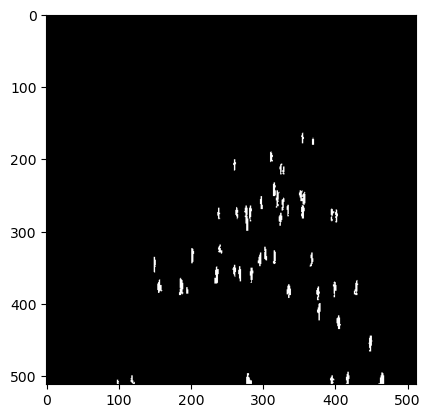

In [36]:
### VISUALIZANDO AS CLASSES
plt.imshow(numpy_file[:,:,10], cmap='gray')